In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [4]:
df= pd.read_csv('Walmart.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.shape
df.info()
df.columns
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [6]:
df.isnull().sum()
(df.isnull().sum()/ len(df))*100

Store           0.0
Date            0.0
Weekly_Sales    0.0
Holiday_Flag    0.0
Temperature     0.0
Fuel_Price      0.0
CPI             0.0
Unemployment    0.0
dtype: float64

In [7]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [8]:
df.describe()
df['Store'].nunique()

45

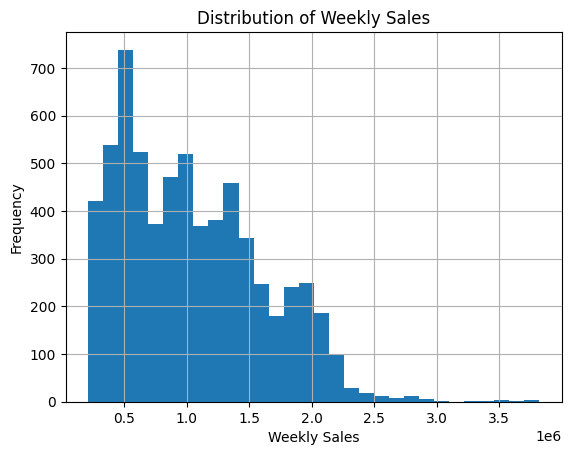

In [9]:
plt.figure()
df['Weekly_Sales'].hist(bins=30)
plt.title('Distribution of Weekly Sales')
plt.xlabel('Weekly Sales')
plt.ylabel('Frequency')
plt.show()


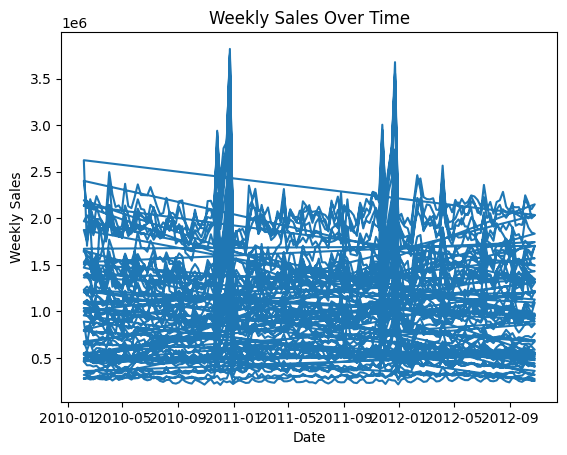

In [10]:
plt.figure()
plt.plot(df['Date'], df['Weekly_Sales'])
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.show()

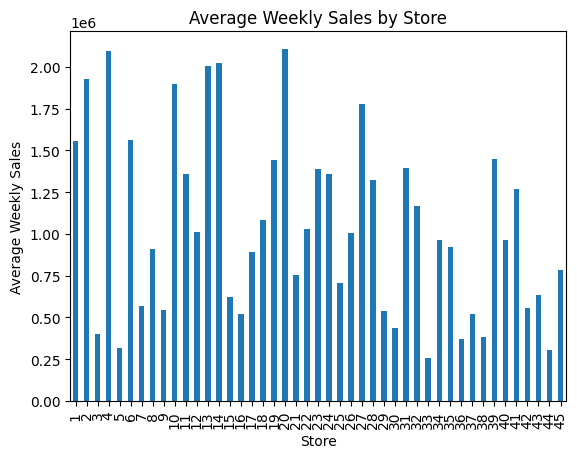

In [11]:
avg_sales_store = df.groupby('Store')['Weekly_Sales'].mean()

plt.figure()
avg_sales_store.plot(kind='bar')
plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.show()

In [12]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
corr_matrix = numeric_df.corr()
corr_matrix

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000


In [13]:
# Compare holiday vs non-holiday sales
df.groupby('Holiday_Flag')['Weekly_Sales'].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

In [14]:
# IQR Method for Weekly_Sales

Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Weekly_Sales'] < lower_bound) | 
              (df['Weekly_Sales'] > upper_bound)]

print("Number of Outliers:", len(outliers))
outliers.head()

Number of Outliers: 34


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,2011-12-23,3224369.80,0,46.66,3.112,218.999550,7.441
471,4,2010-11-26,2789469.45,1,48.08,2.752,126.669267,7.127
474,4,2010-12-17,2740057.14,0,46.57,2.884,126.879484,7.127
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127


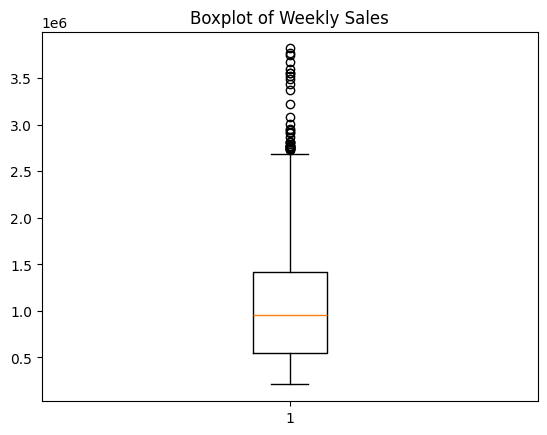

In [15]:
plt.figure()
plt.boxplot(df['Weekly_Sales'])
plt.title("Boxplot of Weekly Sales")
plt.show()

In [16]:
df_clean = df[(df['Weekly_Sales'] >= lower_bound) & 
              (df['Weekly_Sales'] <= upper_bound)]

print("New dataset shape:", df_clean.shape)

New dataset shape: (6401, 8)


<Figure size 640x480 with 0 Axes>

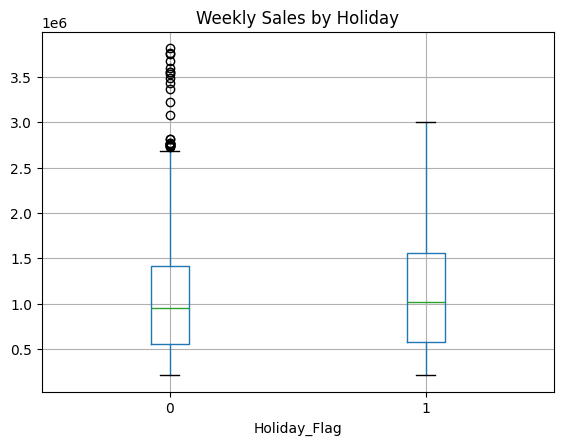

In [17]:
plt.figure()
df.boxplot(column='Weekly_Sales', by='Holiday_Flag')
plt.title("Weekly Sales by Holiday")
plt.suptitle("")
plt.show()

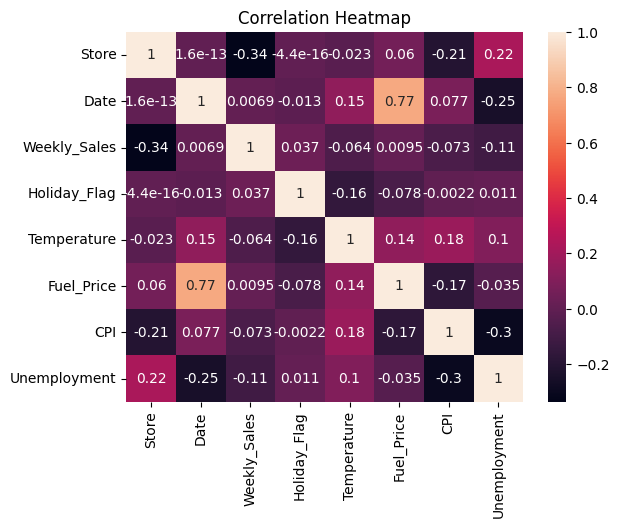

In [18]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

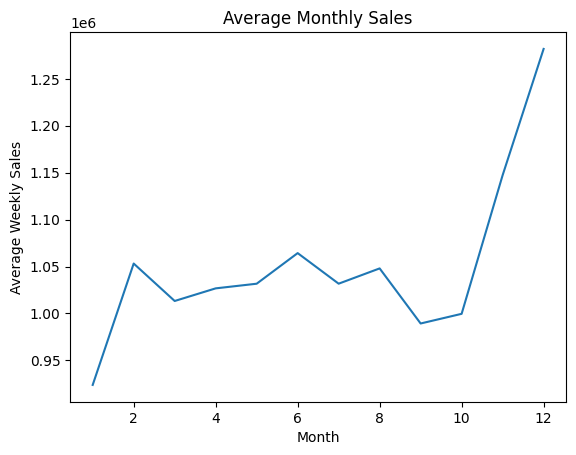

In [19]:
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure()
monthly_sales.plot()
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

In [20]:
df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False).head()

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

In [21]:
# Drop non-numeric or irrelevant columns
model_df = df.copy()

model_df['Month'] = model_df['Date'].dt.month

features = ['Store', 'Holiday_Flag', 'Temperature', 
            'Fuel_Price', 'CPI', 'Unemployment', 'Month']

X = model_df[features]
y = model_df['Weekly_Sales']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})

importance.sort_values(by='Coefficient', ascending=False)

MAE: 432736.6308761738
MSE: 272243420414.5391
R2 Score: 0.15492918523733956


,Feature,Coefficient
1,Holiday_Flag,42819.320029
6,Month,15452.562637
3,Fuel_Price,6344.155771
2,Temperature,-1570.310837
4,CPI,-2211.807005
0,Store,-15152.383134
5,Unemployment,-22070.971730
